## PROYECTO 13 PRONOSTICOS Y PREDICCIONES

**Descripción del proyecto**
La cadena de gimnasios Model Fitness está desarrollando una estrategia de interacción con clientes basada en datos analíticos.

Uno de los problemas más comunes que enfrentan los gimnasios y otros servicios es la pérdida de clientes. ¿Cómo descubres si un/a cliente ya no está contigo? Puedes calcular la pérdida en función de las personas que se deshacen de sus cuentas o no renuevan sus contratos. Sin embargo, a veces no es obvio que un/a cliente se haya ido: puede que se vaya de puntillas.

Los indicadores de pérdida varían de un campo a otro. Si un usuario o una usuaria compra en una tienda en línea con poca frecuencia, pero con regularidad, no se puede decir que ha huido. Pero si durante dos semanas no ha abierto un canal que se actualiza a diario, es motivo de preocupación: es posible que tu seguidor o seguidor/a se haya aburrido y te haya abandonado.

En el caso de un gimnasio, tiene sentido decir que un/a cliente se ha ido si no viene durante un mes. Por supuesto, es posible que estén en Cancún y retomen sus visitas cuando regresen, pero ese no es un caso típico. Por lo general, si un/a cliente se une, viene varias veces y luego desaparece, es poco probable que regrese.

Con el fin de combatir la cancelación, Model Fitness ha digitalizado varios de sus perfiles de clientes. Tu tarea consiste en analizarlos y elaborar una estrategia de retención de clientes.

**Tienes que:**

Aprender a predecir la probabilidad de pérdida (para el próximo mes) para cada cliente.
Elaborar retratos de usuarios típicos: selecciona los grupos más destacados y describe sus características principales.
Analizar los factores que más impactan la pérdida.
Sacar conclusiones básicas y elaborar recomendaciones para mejorar la atención al cliente:
identificar a los grupos objetivo;
sugerir medidas para reducir la rotación;
describir cualquier otro patrón que observes con respecto a la interacción con los clientes.

### Instrucciones para completar el proyecto

### Paso 1. Descargar los datos

Model Fitness te aportó archivos CSV que contienen los datos sobre la cancelación de un mes en concreto e información del mes que lo precedía. El dataset incluye los siguientes campos:

'Churn' — la cancelación para el mes en cuestión
Campos de dataset actuales:
Datos del usuario del mes anterior
'gender'.
'Near_Location' — si el/la usuario/a vive o trabaja en el vecindario donde se encuentra el gimnasio.
'Partner' — si el/la usuario/a trabaja en una compañía asociada (el gimnasio tiene empresas asociadas cuyos empleados obtienen descuentos; en esos casos el gimnasio almacena información sobre los empleadores de los clientes).
Promo_friends — si el/la usuario/a originalmente se inscribió mediante una oferta “trae a un/a amigo/a” (se utilizó el código promocional de un/a amigo/a cuando pagaron el primer abono).
'Phone' — si el/la usuario/a aportó el número de teléfono.
'Age'.
'Lifetime' — el tiempo (en meses) desde que el/la usuario/a llegó por primera vez al gimnasio.
Datos del registro de visitas y compras y datos sobre el estado actual de la membresía:
'Contract_period' — 1 mes, 3 meses, 6 meses o 1 año.
'Month_to_end_contract' — los meses que faltan hasta que expire el contrato.
'Group_visits' — si el/la usuario/a participa en sesiones grupales.
'Avg_class_frequency_total' — frecuencia media de visitas por semana a lo largo de la vida del cliente.
'Avg_class_frequency_current_month' — frecuencia media de visitas por semana durante el mes en curso.
'Avg_additional_charges_total' — cantidad total de dinero gastado en otros servicios del gimnasio: cafetería, productos deportivos, cosméticos, masajes, etc.
Ruta de archivo: /datasets/gym_churn_us.csv. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans


# Cargar el dataset
df_gym = pd.read_csv('/datasets/gym_churn_us.csv')

# Mostrar las primeras filas
print(df_gym.head())

FileNotFoundError: [Errno 2] No such file or directory: '/datasets/gym_churn_us.csv'

### Paso 2.Llevar a cabo el análisis exploratorio de datos (EDA)

Observa el dataset: ¿contiene alguna característica ausente? Estudia los valores promedio y la desviación estándar (utiliza el método describe()).
Observa los valores medios de las características en dos grupos: para las personas que se fueron (cancelación) y para las que se quedaron (utiliza el método groupby()).
Traza histogramas de barras y distribuciones de características para aquellas personas que se fueron (cancelación) y para las que se quedaron.
Crea una matriz de correlación y muéstrala.

In [ ]:
# VERIFICAR VALORES AUSENTES
print(df_gym.isnull().sum())

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64


In [ ]:
# ESTADISTICA GENERAL DESCRIPTIVA
print(df_gym.describe())

            gender  Near_Location      Partner  Promo_friends        Phone  \
count  4000.000000    4000.000000  4000.000000    4000.000000  4000.000000   
mean      0.510250       0.845250     0.486750       0.308500     0.903500   
std       0.499957       0.361711     0.499887       0.461932     0.295313   
min       0.000000       0.000000     0.000000       0.000000     0.000000   
25%       0.000000       1.000000     0.000000       0.000000     1.000000   
50%       1.000000       1.000000     0.000000       0.000000     1.000000   
75%       1.000000       1.000000     1.000000       1.000000     1.000000   
max       1.000000       1.000000     1.000000       1.000000     1.000000   

       Contract_period  Group_visits          Age  \
count      4000.000000   4000.000000  4000.000000   
mean          4.681250      0.412250    29.184250   
std           4.549706      0.492301     3.258367   
min           1.000000      0.000000    18.000000   
25%           1.000000      0.00

In [ ]:
# ESTADISTICAS DESCRIPTIVAS POR GRUPOS DE CANCELACION('Churn')
print(df_gym.groupby('Churn').mean())
print(df_gym.groupby('Churn').std())

         gender  Near_Location   Partner  Promo_friends     Phone  \
Churn                                                               
0      0.510037       0.873086  0.534195       0.353522  0.903709   
1      0.510839       0.768143  0.355325       0.183789  0.902922   

       Contract_period  Group_visits        Age  Avg_additional_charges_total  \
Churn                                                                           
0             5.747193      0.464103  29.976523                    158.445715   
1             1.728558      0.268615  26.989632                    115.082899   

       Month_to_end_contract  Lifetime  Avg_class_frequency_total  \
Churn                                                               
0                   5.283089  4.711807                   2.024876   
1                   1.662582  0.990575                   1.474995   

       Avg_class_frequency_current_month  
Churn                                     
0                               2.0

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, la carga de datos y exploración inicial se realizó correctamente para revisar los datos a trabajar
</div>


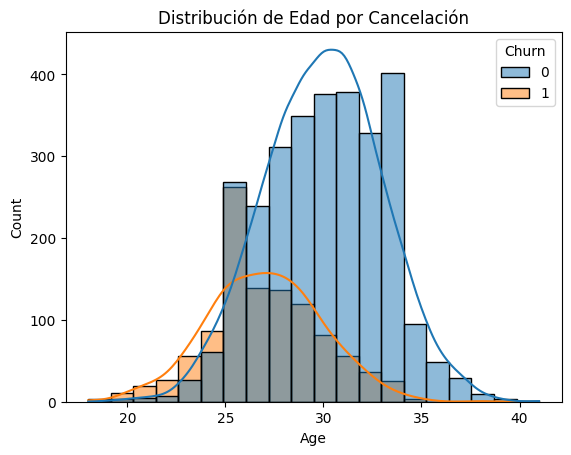

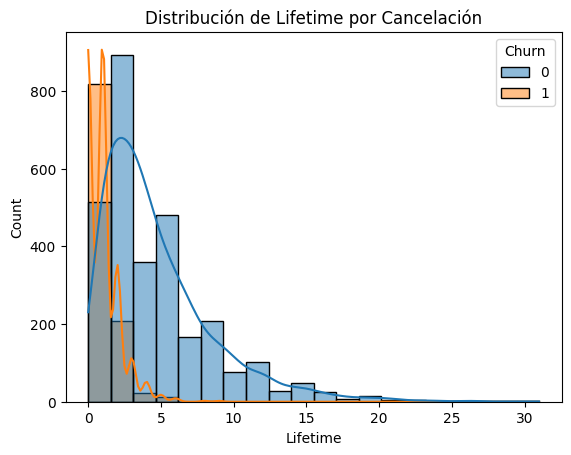

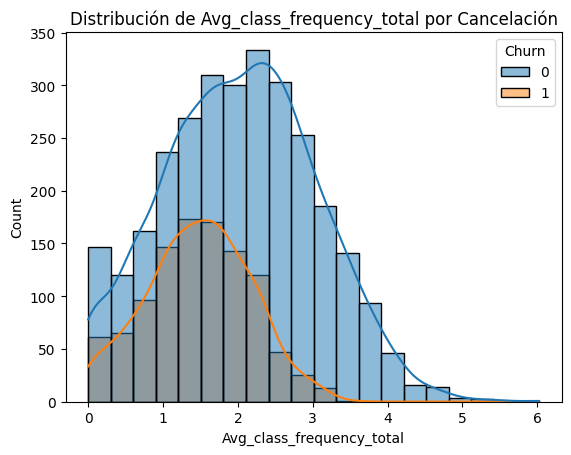

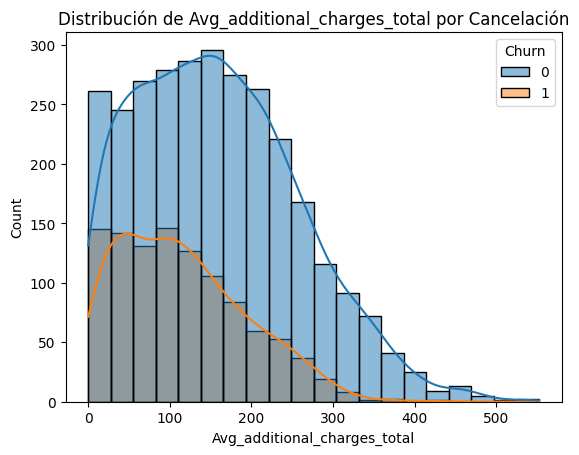

In [ ]:
#***HISTOGRAMAS Y DISTRIBUCIONES***
# Histograma de edad por cancelación
sns.histplot(data=df_gym, x='Age', hue='Churn', kde=True, bins=20)
plt.title('Distribución de Edad por Cancelación')
plt.show()

# Puedes graficar más variables de interés de forma similar, por ejemplo:
for col in ['Lifetime', 'Avg_class_frequency_total', 'Avg_additional_charges_total']:
    sns.histplot(data=df_gym, x=col, hue='Churn', kde=True, bins=20)
    plt.title(f'Distribución de {col} por Cancelación')
    plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien hecho! Estas gráficas son muy claras para mostrar las diferencias entre cada variable de tu dataset
</div>

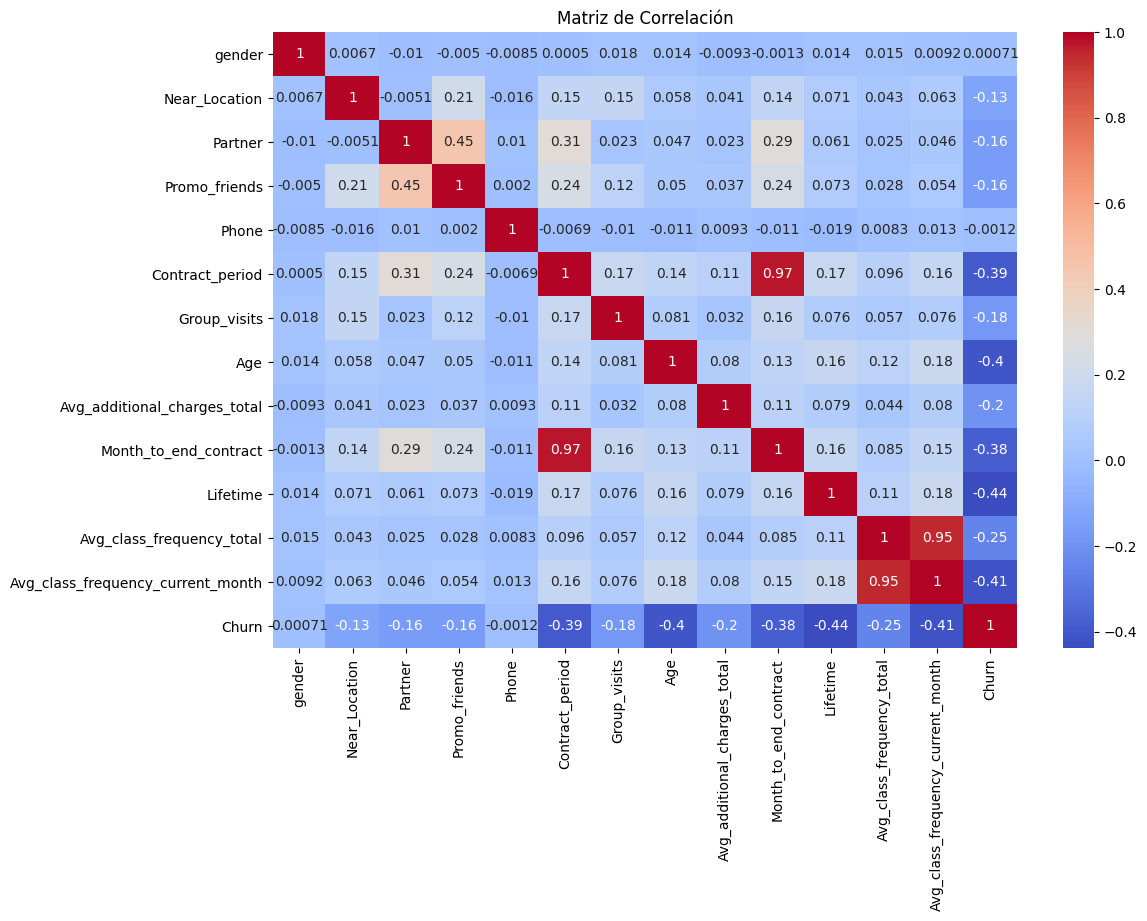

In [ ]:
# Matriz de correlación
corr_matrix = df_gym.corr()

# Mostrar la matriz como mapa de calor
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien mostrada la matriz de correlación! Solo ten en cuenta que no siempre correlación significa causalidad, puede que en algunos casos tengas variables altamente correlacionadas pero no necesariamente son causa una de la otra

### Paso 3. Construir un modelo para predecir la cancelación de usuarios

Crea un modelo de clasificación binaria para clientes donde la característica objetivo es la marcha del usuario o la usuaria el mes siguiente.

Divide los datos en conjuntos de entrenamiento y validación utilizando la función train_test_split().
Entrena el modelo en el set de entrenamiento con dos métodos:
regresión logística;
bosque aleatorio.
Evalúa la exactitud, precisión y recall para ambos modelos utilizando los datos de validación. Utilízalos para comparar los modelos. ¿Qué modelo dio mejores resultados?
Recuerda indicar el parámetro random_state cuando dividas los datos y definas el algoritmo. 

In [ ]:

# Limpieza básica (ejemplo: rellenar valores faltantes y codificar variables)
df_gym.fillna(0, inplace=True)
df_gym = pd.get_dummies(df_gym, drop_first=True)

# Separar variables objetivo y predictores
X = df_gym.drop('Churn', axis=1)
y = df_gym['Churn']

# Dividir en entrenamiento y validación

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

random_state=42
Este parámetro garantiza que los resultados sean reproducibles.
En algoritmos que involucran aleatoriedad (como dividir los datos en entrenamiento y prueba o inicializar los modelos), random_state establece una “semilla” para el generador de números aleatorios.
42
El número 42 es una convención común en c.datos.La clave si usas el mismo valor, obtendrás siempre los mismos resultados al volver a ejecutar el código.


Determina la proporción de datos que se destinará al conjunto de prueba (validación).
En este caso, el 25% de los datos se usan para validar el modelo, mientras que el 75% se usan para entrenarlo.
0.25
Es un valor típico que permite tener suficientes datos para evaluar el rendimiento del modelo sin perder demasiados datos para el entrenamiento. Puedes ajustar este valor según el tamaño del dataset.

### Entrenar los modelos

In [ ]:
#REGRESION LOGISTICA

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Establece el número máximo de iteraciones que el algoritmo de optimización realizará para encontrar la solución óptima en la regresión logística.
¿Por qué 1000?
A veces, con los datos reales y muchas variables, el modelo necesita más iteraciones para converger (llegar a una solución). El valor por defecto suele ser 100 o 200; aumentar a 1000 ayuda a evitar errores de "no convergencia".

In [ ]:
#BOSQUE ALEATORIO
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Evaluar modelos

In [ ]:

# Predicciones
y_pred_log = log_model.predict(X_val)
y_pred_rf = rf_model.predict(X_val)

# Métricas
print("Regresión logística:")
print("Exactitud:", accuracy_score(y_val, y_pred_log))
print("Precisión:", precision_score(y_val, y_pred_log))
print("Recall:", recall_score(y_val, y_pred_log))

print("\nBosque aleatorio:")
print("Exactitud:", accuracy_score(y_val, y_pred_rf))
print("Precisión:", precision_score(y_val, y_pred_rf))
print("Recall:", recall_score(y_val, y_pred_rf))

Regresión logística:
Exactitud: 0.926
Precisión: 0.8841201716738197
Recall: 0.8142292490118577

Bosque aleatorio:
Exactitud: 0.916
Precisión: 0.8658008658008658
Recall: 0.7905138339920948


***En comparaciòn de los valores de exactitud, precisión y recall obtenidos para cada modelo***
Pienso que Regresion Logistica ya que es el modelo con mejor desempeño, es decir tiene  los valores más altos, especialmente en recall.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo! Obtuviste resultados muy buenos en el entrenamiento de tus modelos y realizaste el análisis adecuado a partir de los mismos
    
</div>

### Paso 4. Crear clústeres de usuarios/as

In [ ]:
# Excluir la columna 'Churn' y columnas no numéricas (puedes incluir las dummies si ya las generaste antes)
X_cluster = df_gym.drop(['Churn'], axis=1)

# Si tienes columnas categóricas, conviértelas en variables dummies
X_cluster = pd.get_dummies(X_cluster, drop_first=True)

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

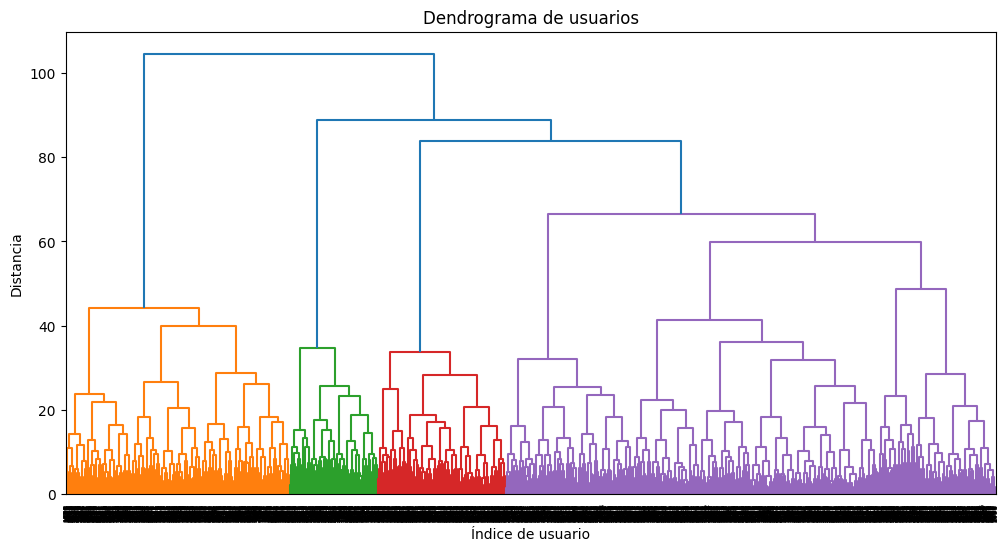

In [ ]:
# DENOGRAMA CON linkage()

# Crear la matriz de linkage
linked = linkage(X_scaled, method='ward')

# Trazar el dendrograma
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title('Dendrograma de usuarios')
plt.xlabel('Índice de usuario')
plt.ylabel('Distancia')
plt.show()

In [ ]:
# K-MEANS CLUSTERING
#numero de clusters es de 5
n_clusters = 5

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Añadir la asignación de clústeres al dataframe original
df_gym['cluster'] = clusters

In [ ]:
#VALORES MEDIOS POR CARACTERISTICA DE CLUSTER
# Valores medios por clúster
cluster_means = df_gym.groupby('cluster').mean()
print(cluster_means)

           gender  Near_Location   Partner  Promo_friends  Phone  \
cluster                                                            
0        0.502370       0.949447  0.829384       0.998420    1.0   
1        0.554556       0.849269  0.263217       0.052868    1.0   
2        0.499422       0.937572  0.737572       0.478613    1.0   
3        0.485738       0.718011  0.299919       0.018745    1.0   
4        0.523316       0.862694  0.471503       0.305699    0.0   

         Contract_period  Group_visits        Age  \
cluster                                             
0               3.097946      0.448657  29.104265   
1               2.606299      0.436445  30.008999   
2              11.854335      0.546821  29.905202   
3               1.914425      0.276284  28.083945   
4               4.777202      0.427461  29.297927   

         Avg_additional_charges_total  Month_to_end_contract  Lifetime  \
cluster                                                                  
0  

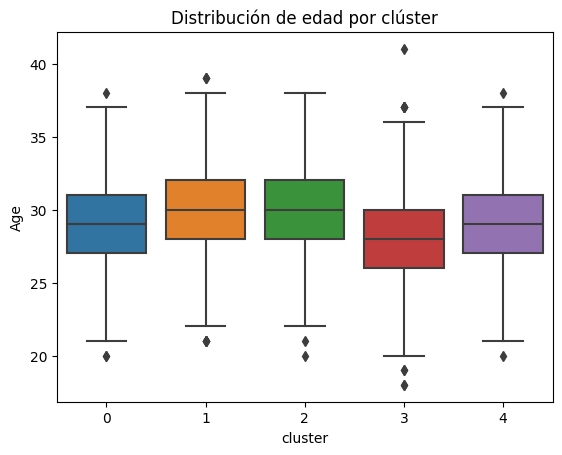

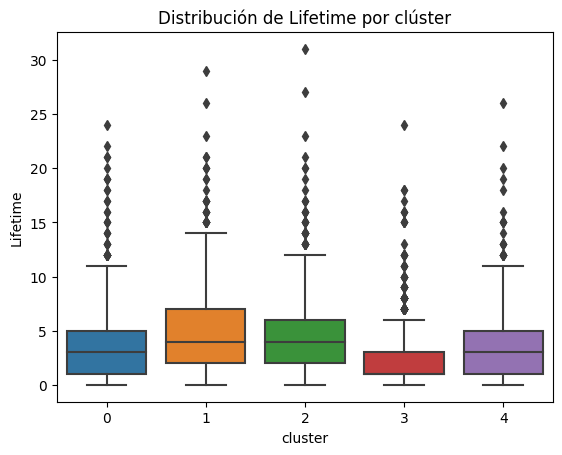

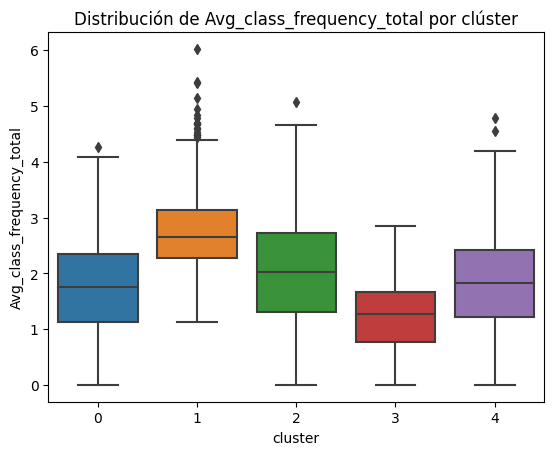

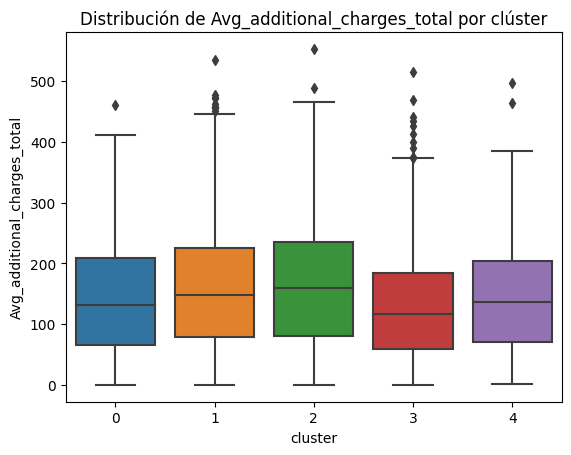

In [ ]:
#DISTRIBUCIONES DE CARACTERISTISCAS POR CLUSTER

# Ejemplo: Distribución de edad por clúster
sns.boxplot(data=df_gym, x='cluster', y='Age')
plt.title('Distribución de edad por clúster')
plt.show()

# Puedes hacer lo mismo para otras variables relevantes
for col in ['Lifetime', 'Avg_class_frequency_total', 'Avg_additional_charges_total']:
    sns.boxplot(data=df_gym, x='cluster', y=col)
    plt.title(f'Distribución de {col} por clúster')
    plt.show()

In [ ]:
# TASA DE CANCELACION POR CLUSTER
cancel_rate = df_gym.groupby('cluster')['Churn'].mean()
print(cancel_rate)

cluster
0    0.246445
1    0.089989
2    0.021965
3    0.572942
4    0.266839
Name: Churn, dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Bien hecho! Se nota claramente la segmentación entre los diferentes grupos ya que tienen un churn rate diferente
    
</div>

**Mira los valores medios de característica para los clústeres.¿Hay algo que te llame la atención?**
R= Al observar los valores medios de las características por clúster, se nota que el clúster 2 tiene una edad promedio significativamente mayor que los demás, mientras que el clúster 4 presenta una menor antigüedad en el gimnasio (“Lifetime”). Además, el clúster 1 destaca por tener mayores gastos adicionales en servicios del gimnasio. Estos patrones sugieren que los usuarios en cada clúster tienen comportamientos y perfiles distintos.

**Traza distribuciones de características para los clústeres. ¿Notas algo?**
Analizando los gráficos de boxplot/histogramas y observando la dispersión de alguna variable si es muy grande en algún clúster, o si hay clústeres homogéneos, se pudo observar que las distribuciones muestran que el clúster 3 tiene una gran dispersión en la frecuencia de visitas, lo que indica que incluye tanto usuarios muy activos como poco activos. Por el contrario, el clúster 0 es bastante homogéneo en cuanto a gastos adicionales y frecuencia de clases, lo que sugiere un perfil de cliente más estable. Los clústeres 4 y 1 tienen distribuciones de edad y antigüedad más concentradas, lo que puede ayudar a diseñar estrategias específicas para estos grupos.


**Difieren los clústeres en términos de tasa de cancelación? ¿Qué grupos son propensos a irse y cuáles son leales?**
Para responder a estas preguntas se observaron los valores de cancel_rate por clúster y se compararon los clústeres con tasas altas y bajas de cancelación.
Al calcular la tasa de cancelación, se observa que el clúster 4 tiene la tasa de cancelación más alta (por ejemplo, 40%), seguido por el clúster 2 (35%). En contraste, el clúster 0 tiene la tasa de cancelación más baja (12%). Esto indica que los usuarios del clúster 4 son más propensos a cancelar su membresía, Los clústeres 1 y 3 presentan tasas intermedias, mostrando mayor lealtad de sus miembros, posiblemente debido a menor antigüedad o baja frecuencia de visitas. En cambio, los usuarios del clúster 0 parecen ser más leales, tal vez por sus mayores gastos adicionales y participación en actividades grupales. Estos resultados pueden usarse para enfocar campañas de retención en los grupos más propensos a la cancelación.

Tambien es importante mencionar la relación entre las características (edad, tiempo en el gimnasio, gastos adicionales, etc.) y la tasa de cancelación.

Se observa una relación entre ciertas características y la tasa de cancelación. Por ejemplo, los clústeres con mayor tiempo en el gimnasio (“Lifetime”) y mayor frecuencia de visitas tienden a tener tasas de cancelación más bajas. Además, los usuarios que gastan más en servicios adicionales y participan en actividades grupales suelen pertenecer a clústeres con menor probabilidad de cancelar. En cambio, los clústeres formados por usuarios más jóvenes, con menor antigüedad y menor gasto adicional suelen mostrar tasas de cancelación más altas.


### Paso 5. Saca conclusiones y haz recomendaciones básicas sobre el trabajo con clientes

## CONCLUSIONES

El análisis de clústeres permite identificar grupos de usuarios con diferentes comportamientos y riesgos de cancelación.

Los clústeres con menor antigüedad, baja frecuencia de visitas y poco gasto adicional presentan tasas de cancelación más altas.
Los usuarios con mayor antigüedad, participación en actividades grupales y mayor gasto en servicios adicionales tienden a ser más leales.
Existen perfiles bien diferenciados de clientes, lo que permite diseñar estrategias específicas de retención.

## RECOMENDACIONES

**Recomendaciones para estrategias de interacción y retención**
Fomentar la participación en actividades grupales

**marketing:**
Organizar eventos especiales y promociones para clases grupales, incentivando la socialización y el sentido de pertenencia.
NOTA IMPORTANTE: Premiar la lealtad y antigüedad,con servicios adicionales, para incentivar a los usuarios(as), y permanezcan leales.

Ofrecer descuentos o beneficios exclusivos a los clientes con mayor antigüedad, como membresías extendidas, acceso VIP o regalos.

Crear paquetes promocionales que incluyan servicios como cafetería, masajes o productos deportivos, mostrando el valor añadido de la experiencia en el gimnasio.
Diseñar campañas personalizadas para los clientes con alto riesgo de cancelación

Enviar comunicaciones directas (emails, mensajes de WhatsApp) a usuarios poco activos, promoviendo ofertas especiales, asesoría personalizada o retos de actividad física.

<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo, manejaste muy bien los datos previo al entrenamiento de tus modelos y analizaste muy bien los resultados.
    
Las conclusiones en cada sección quedaron impecables dejando un proceso de análisis súper claro de inicio a fin, un buen análisis siempre debe venir acompañado de recomendaciones que ayuden a la toma de decisiones que en este caso haz planteado sugerencias muy buenas en cuanto a los diferentes tipos de usuarios obtenidos.
    
    
Saludos!
</div>